# FIG5: Accuracy-latency trade-offs of the optimization-based forward dynamics solver

This notebook regenerates manuscript Figure 5 from the packaged data archive `FIG5.zip`.
The archive must be in the same folder as this notebook. The notebook saves `FIG5.svg`, `FIG5.pdf` and `FIG5.png`.

Saved FIG5.svg
Saved FIG5.pdf


Saved FIG5.png


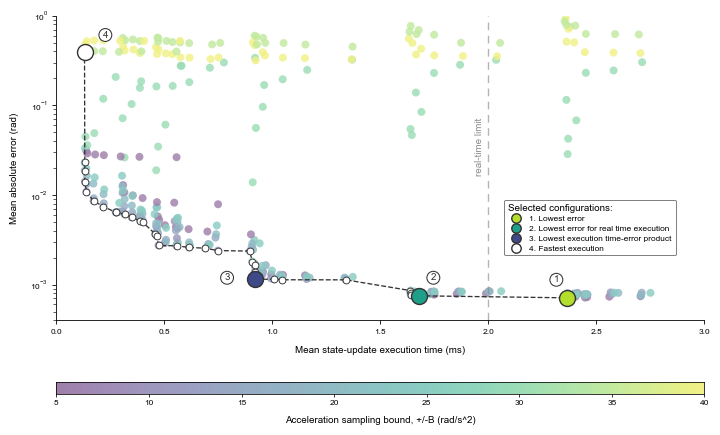

Grid-search configurations: 336
Pareto-front operating points: 34
Highlighted operating points:
callout                            selection         point_label  mean_abs_angle_error_rad  mean_update_ms  runs_faster_than_real_time  time_angle_error_product
      1                         Lowest error N=16, B=+/-20, A=15                  0.000712        2.366197                       False                  0.001685
      2 Lowest error for real time execution N=16, B=+/-15, A=10                  0.000750        1.680996                        True                  0.001261
      3  Lowest execution time-error product  N=32, B=+/-10, A=5                  0.001150        0.918909                        True                  0.001057
      4                    Fastest execution  N=16, B=+/-35, A=0                  0.397097        0.130361                        True                  0.051766


In [1]:
from pathlib import Path
import json
import zipfile

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# Load packaged data. FIG5.zip must be in the same folder as this notebook.
# -----------------------------------------------------------------------------
DATA_ARCHIVE = Path("FIG5.zip")
if not DATA_ARCHIVE.exists():
    DATA_ARCHIVE = Path("FIG5")
if not DATA_ARCHIVE.exists():
    raise FileNotFoundError(
        "Could not find FIG5.zip or FIG5 in the current folder. "
        "Place the data archive in the same folder as FIG5.ipynb."
    )

with zipfile.ZipFile(DATA_ARCHIVE) as archive:
    grid_df = pd.read_csv(archive.open("fig5_optimizer_grid_search.csv"))
    archived_pareto_df = pd.read_csv(archive.open("fig5_pareto_front.csv"))
    archived_highlight_df = pd.read_csv(archive.open("fig5_highlighted_operating_points.csv"))
    metadata = json.load(archive.open("fig5_metadata.json"))

REALTIME_STEP_MS = float(metadata["real_time_step_ms"])
GRID_UNIFORM_BOUNDS = [float(v) for v in metadata["grid"]["uniform_acceleration_bounds_B_rad_s2"]]

# -----------------------------------------------------------------------------
# Figure style.
# -----------------------------------------------------------------------------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.45,
    "ytick.minor.width": 0.45,
    "lines.linewidth": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "savefig.dpi": 600,
})

neutral_dark = "#333333"
neutral_mid = "#8A8D91"


def blend_with_white(color, amount):
    rgb = np.array(mcolors.to_rgb(color), dtype=float)
    return tuple(rgb * (1.0 - amount) + amount)

# A lightened viridis map keeps the non-joint parameter encoding visually separate
# from the manuscript's joint-specific blue/red convention.
base_colors = [plt.cm.viridis(v) for v in np.linspace(0.02, 0.96, 256)]
pastel_colors = [blend_with_white(c, 0.48) for c in base_colors]
bound_cmap = mpl.colors.LinearSegmentedColormap.from_list("fig5_pastel_viridis", pastel_colors, N=256)
bound_norm = mpl.colors.Normalize(vmin=min(GRID_UNIFORM_BOUNDS), vmax=max(GRID_UNIFORM_BOUNDS))

highlight_colors = {
    "1": "#B4DE2C",
    "2": "#1F9E89",
    "3": "#3E4989",
    "4": "white",
}


def pareto_front(df, x_col, y_col):
    ordered = df.sort_values([x_col, y_col])
    best_y = float("inf")
    keep_rows = []
    for _, row in ordered.iterrows():
        if row[y_col] <= best_y:
            keep_rows.append(row)
            best_y = row[y_col]
    return pd.DataFrame(keep_rows).reset_index(drop=True)


def compact_config_label(row):
    return f"N={int(row['candidate_count'])}, B=+/-{row['bound']:g}, A={int(row['adam_steps'])}"


def get_highlight_row(callout_number):
    match = archived_highlight_df.loc[archived_highlight_df["callout_number"].astype(str) == str(callout_number)]
    if match.empty:
        raise ValueError(f"Missing callout {callout_number} in fig5_highlighted_operating_points.csv")
    label = match.iloc[0]["label"]
    row = grid_df.loc[grid_df["label"] == label]
    if row.empty:
        raise ValueError(f"Highlight label {label} is absent from fig5_optimizer_grid_search.csv")
    return row.iloc[0]

plot_df = grid_df.copy()
pareto_df = pareto_front(plot_df, "mean_update_ms", "mean_abs_angle_error_rad")

# Check that the archived Pareto front equals the one recomputed for plotting.
if len(pareto_df) != len(archived_pareto_df):
    raise ValueError("Pareto-front row count does not match archived derived table.")
if not np.allclose(
    pareto_df[["mean_update_ms", "mean_abs_angle_error_rad"]].to_numpy(float),
    archived_pareto_df[["mean_update_ms", "mean_abs_angle_error_rad"]].to_numpy(float),
    rtol=0,
    atol=1e-12,
):
    raise ValueError("Recomputed Pareto front does not match archived derived table.")

highlight_specs = [
    ("1", "Lowest error", get_highlight_row("1")),
    ("2", "Lowest error for real time execution", get_highlight_row("2")),
    ("3", "Lowest execution time-error product", get_highlight_row("3")),
    ("4", "Fastest execution", get_highlight_row("4")),
]

# -----------------------------------------------------------------------------
# Plot Figure 5.
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.20, 4.23), constrained_layout=False)
fig.subplots_adjust(left=0.085, right=0.985, top=0.97, bottom=0.25)

scatter = ax.scatter(
    plot_df["mean_update_ms"],
    plot_df["mean_abs_angle_error_rad"],
    c=plot_df["bound"],
    cmap=bound_cmap,
    norm=bound_norm,
    s=33,
    alpha=0.82,
    edgecolors="none",
    zorder=1,
)

ax.plot(
    pareto_df["mean_update_ms"],
    pareto_df["mean_abs_angle_error_rad"],
    color=neutral_dark,
    linewidth=0.95,
    linestyle="--",
    zorder=3,
)
ax.scatter(
    pareto_df["mean_update_ms"],
    pareto_df["mean_abs_angle_error_rad"],
    s=24,
    facecolors="white",
    edgecolors=neutral_dark,
    linewidths=0.65,
    zorder=4,
)

ax.axvline(
    REALTIME_STEP_MS,
    color=neutral_mid,
    linewidth=1.0,
    linestyle=(0, (5.5, 4.0)),
    alpha=0.65,
    zorder=2,
)
ax.text(
    REALTIME_STEP_MS - 0.02,
    0.035,
    "real-time limit",
    rotation=90,
    ha="right",
    va="center",
    color=neutral_mid,
    fontsize=7,
)

callout_offsets = {
    "1": (-8, 13),
    "2": (10, 13),
    "3": (-20, 1),
    "4": (15, 12),
}

for callout, _, row in highlight_specs:
    facecolor = highlight_colors[callout]
    ax.scatter(
        row["mean_update_ms"],
        row["mean_abs_angle_error_rad"],
        marker="o",
        s=132,
        facecolors=facecolor,
        edgecolors=neutral_dark,
        linewidths=1.0,
        zorder=6,
    )
    ax.annotate(
        callout,
        (row["mean_update_ms"], row["mean_abs_angle_error_rad"]),
        xytext=callout_offsets[callout],
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=7,
        color=neutral_dark,
        bbox={
            "boxstyle": "circle,pad=0.20",
            "facecolor": "white",
            "edgecolor": neutral_dark,
            "linewidth": 0.75,
        },
        zorder=7,
    )

legend_handles = [
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=highlight_colors[callout],
           markeredgecolor=neutral_dark, markeredgewidth=1.0, markersize=6.8,
           label=f"{callout}. {label}")
    for callout, label, _ in highlight_specs
]
legend = ax.legend(
    handles=legend_handles,
    title="Selected configurations:",
    loc="lower left",
    bbox_to_anchor=(0.685, 0.20),
    frameon=True,
    facecolor="white",
    edgecolor=neutral_dark,
    borderpad=0.45,
    labelspacing=0.35,
    handletextpad=0.55,
)
legend._legend_box.align = "left"
legend.get_frame().set_linewidth(0.55)
legend.get_title().set_fontsize(7)

ax.set_xlabel("Mean state-update execution time (ms)", labelpad=8)
ax.set_ylabel("Mean absolute error (rad)", labelpad=8)
ax.set_xlim(0.0, 3.0)
ax.set_ylim(4e-4, 1.0)
ax.set_yscale("log")
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.yaxis.set_major_locator(mticker.LogLocator(base=10.0, numticks=5))
ax.yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=40))
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10.0))
ax.tick_params(axis="both", which="major", direction="out", length=3.0, width=0.6, pad=3)
ax.tick_params(axis="y", which="minor", direction="out", length=2.0, width=0.45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

# Horizontal colorbar beneath the main axis. Drawn as vector rectangles so
# the SVG/PDF remain editable in Illustrator rather than embedding a raster strip.
cbar_ax = fig.add_axes([0.085, 0.075, 0.90, 0.030])
cbar_ax.set_xlim(min(GRID_UNIFORM_BOUNDS), max(GRID_UNIFORM_BOUNDS))
cbar_ax.set_ylim(0, 1)
n_segments = 160
bound_edges = np.linspace(min(GRID_UNIFORM_BOUNDS), max(GRID_UNIFORM_BOUNDS), n_segments + 1)
for left, right in zip(bound_edges[:-1], bound_edges[1:]):
    mid = 0.5 * (left + right)
    cbar_ax.add_patch(
        plt.Rectangle(
            (left, 0),
            right - left,
            1,
            facecolor=bound_cmap(bound_norm(mid)),
            edgecolor="none",
            linewidth=0,
        )
    )
cbar_ax.set_yticks([])
cbar_ax.set_xticks(GRID_UNIFORM_BOUNDS)
cbar_ax.set_xlabel("Acceleration sampling bound, +/-B (rad/s^2)", labelpad=7)
cbar_ax.tick_params(axis="x", direction="out", length=2.3, width=0.55, pad=2)
for spine in cbar_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.55)

for ext in ["svg", "pdf", "png"]:
    path = Path(f"FIG5.{ext}")
    if ext == "png":
        fig.savefig(path, dpi=600, bbox_inches=None, facecolor="white")
    else:
        fig.savefig(path, bbox_inches=None, facecolor="white")
    print(f"Saved {path}")

plt.show()

print(f"Grid-search configurations: {len(plot_df)}")
print(f"Pareto-front operating points: {len(pareto_df)}")
print("Highlighted operating points:")
summary_cols = [
    "callout", "selection", "point_label", "mean_abs_angle_error_rad",
    "mean_update_ms", "runs_faster_than_real_time", "time_angle_error_product",
]
summary_rows = []
for callout, selection, row in highlight_specs:
    summary_rows.append({
        "callout": callout,
        "selection": selection,
        "point_label": compact_config_label(row),
        "mean_abs_angle_error_rad": row["mean_abs_angle_error_rad"],
        "mean_update_ms": row["mean_update_ms"],
        "runs_faster_than_real_time": row["runs_faster_than_real_time"],
        "time_angle_error_product": row["time_angle_error_product"],
    })
print(pd.DataFrame(summary_rows)[summary_cols].to_string(index=False))